## Regression models 
This notebook compares regression models for predicting 'HealthImpactScore', a continuous health outcome variable. We will use air quality and weather variables as predictors and compare model-performance using 10-fold cross-validation. 

In [14]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from sklearn.model_selection import KFold, cross_validate, GridSearchCV, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import LinearRegression, Lasso
from sklearn.decomposition import PCA
from sklearn.metrics import mean_squared_error, r2_score

sns.set_style("whitegrid")


## Load the Dataset 

In [15]:
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_PATH = PROJECT_ROOT / "data" / "raw"/ "air_quality_health_impact_data.csv"

df = pd.read_csv(DATA_PATH)

df.head()

,RecordID,AQI,PM10,PM2_5,NO2,SO2,O3,Temperature,Humidity,WindSpeed,RespiratoryCases,CardiovascularCases,HospitalAdmissions,HealthImpactScore,HealthImpactClass
0,1,187.270059,295.853039,13.038560,6.639263,66.161150,54.624280,5.150335,84.424344,6.137755,7,5,1,97.244041,0.0
1,2,475.357153,246.254703,9.984497,16.318326,90.499523,169.621728,1.543378,46.851415,4.521422,10,2,0,100.000000,0.0
2,3,365.996971,84.443191,23.111340,96.317811,17.875850,9.006794,1.169483,17.806977,11.157384,13,3,0,100.000000,0.0
3,4,299.329242,21.020609,14.273403,81.234403,48.323616,93.161033,21.925276,99.473373,15.302500,8,8,1,100.000000,0.0
4,5,78.009320,16.987667,152.111623,121.235461,90.866167,241.795138,9.217517,24.906837,14.534733,9,0,1,95.182643,0.0


## Define Predictors and Target 
The target vairable is 'HealthImpactScore'.

The predictors include air quality and weather measurements. We exclude:
- 'RecordID', because it is only an identifier. 
- 'HealthImpactClass', because it is a seperate categorical outcome.
- Health case counts, because they are also health-related outcomes rather than environmnetal predictors 

In [16]:
predictors = [
    'AQI',
    'PM10',
    'PM2_5',
    'NO2',
    'SO2',
    'O3',
    'Temperature',
    'Humidity',
    'WindSpeed',
]

X = df[predictors]
y = df['HealthImpactScore']

print("Predictors:", predictors)
print("Predictor shape:", X.shape)
print("Target shape:", y.shape)

Predictors: ['AQI', 'PM10', 'PM2_5', 'NO2', 'SO2', 'O3', 'Temperature', 'Humidity', 'WindSpeed']
Predictor shape: (5811, 9)
Target shape: (5811,)


## Train/Test Split and Cross-Validation 
We reserve 20% of the dataset as a final test set. The remaining 80% is used for training and model selection.

Within the training data, we use shuffled 10-fold cross-validation:
- The training data is divided into 10 folds. 
- Each model is trained on 9 folds and validated on the remaining fold. 
- This repeats unitl every fold has been used for validation once. 

How to read the metrics:
- 'RMSE' measures prediction error. Lower values are better.
- 'R-squared' measures how much variation in 'HealthImpactScore' is explained by the model. Higher values are better. 

In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X, 
    y, 
    test_size=0.2, 
    random_state=42
)

cv = KFold(n_splits=10, shuffle=True, random_state=42)

print("Training rows:", X_train.shape[0])
print("Testing rows:", X_test.shape[0])

Training rows: 4648
Testing rows: 1163


In [18]:
def cross_validation_summary(model_name, model):
    scores = cross_validate(
        model,
        X_train,
        y_train,
        cv=cv,
        scoring = {
            "rmse": "neg_root_mean_squared_error",
            "r2": "r2"  
        }
    )

    return {
        "Model": model_name,
        "Mean CV RMSE": -scores["test_rmse"].mean(),
        "Mean CV R-squared": scores["test_r2"].mean()
    }

def test_summary(model_name, model):
    model.fit(X_train, y_train)
    preditction = model.predict(X_test)

    return {
        "Model": model_name,
        "Test RMSE": np.sqrt(mean_squared_error(y_test, preditction,)),
        "Test R-squared": r2_score(y_test, preditction)
    }

## Multiple Linear Regression Baseline 
Multiple Linear Regression estimates a linear relationship between the environmental predictors and 'HeathImpactScore'. This gives us a baseline for comparing other models.

In [21]:
linear_model = Pipeline([
    ("scaler", StandardScaler()),
    ("LinearRegression", LinearRegression())
])

linear_cv = cross_validation_summary("Multiple Linear Regression", linear_model)

pd.DataFrame([linear_cv])

,Model,Mean CV RMSE,Mean CV R-squared
0,Multiple Linear Regression,9.462888,0.482713


How to read the output:
- 'Mean CV RMSE' is the average prediction error across the validation folds. 
- 'Mean CV R-squared' measures the average proportion of variation explained by the model. 
- This baseline will be compared with more flexible models below.


## Lasso Regression
Lasso Regression adds regularization to a linear regression model. This can reduce the influence of weaker predictors and may set some coefficients close to zero. 

We compare several 'alpha' values:
- Smaller values apply weaker regularization. 
- Larger values apply stronger regularization.
- The best value is the one with the lowest cross-validation RMSE.

In [26]:
lasso_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("lasso", Lasso(max_iter=100000))
])

lasso_search = GridSearchCV(
    estimator=lasso_pipeline,
    param_grid={
        "lasso__alpha": np.logspace(-4, 2, 13)
    },
    scoring="neg_root_mean_squared_error",
    cv=cv
)

lasso_search.fit(X_train, y_train)

print("Best alpha:", lasso_search.best_params_["lasso__alpha"])
print("Best CV RMSE:", -lasso_search.best_score_)



Best alpha: 0.03162277660168379
Best CV RMSE: 9.46248507521383


In [27]:
lasso_results = pd.DataFrame({
    "Alpha": lasso_search.cv_results_["param_lasso__alpha"].astype(float),
    "Mean CV RMSE": -lasso_search.cv_results_["mean_test_score"]
}).sort_values("Alpha")

lasso_results

,Alpha,Mean CV RMSE
0,0.000100,9.462887
1,0.000316,9.462884
2,0.001000,9.462874
3,0.003162,9.462847
4,0.010000,9.462749
5,0.031623,9.462485
6,0.100000,9.463535
7,0.316228,9.483445
8,1.000000,9.709037
9,3.162278,10.900611


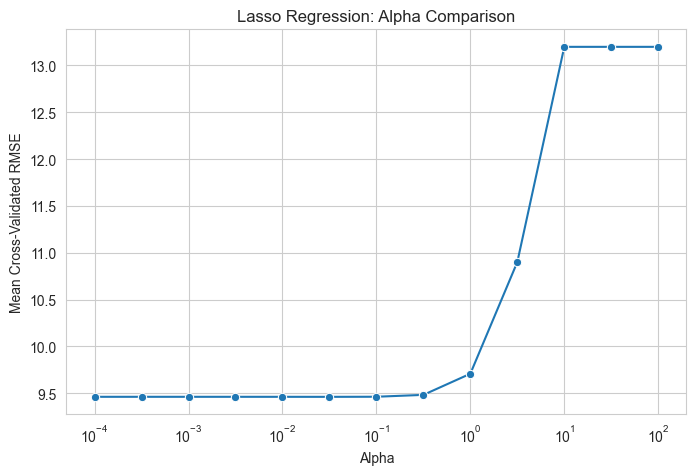

In [28]:
plt.figure(figsize=(8, 5))
sns.lineplot(data=lasso_results, x="Alpha", y="Mean CV RMSE", marker="o")
plt.xscale("log")
plt.title("Lasso Regression: Alpha Comparison")
plt.xlabel("Alpha")
plt.ylabel("Mean Cross-Validated RMSE")
plt.show()

How to read the plot:
- Each point respresents one regularization strength.
- Lower RMSE values indicate better performance.
- The selected alpha value has the lowest cross-validation RMSE. 

## Polynomial Regression 
Polynomial Regression test whether nonlinear relationships improve predictions.

We compare:
- Degree '1': linear model 
- Degree '2': adds squared terms and interactions 
- Degree '3': adds more nonlinear terms 
- Degree '5': creates a more flexible model 

Higher degress may fit complex patterns, but they may also overfit. Cross-validation helps identify the best degree.

In [30]:
polynomial_pipeline = Pipeline([
    ("polynomial_features", PolynomialFeatures(include_bias=False)),
    ("scaler", StandardScaler()),
    ("LinearRegression", LinearRegression())
])

polynomia_search = GridSearchCV(
    estimator=polynomial_pipeline,
    param_grid={
        "polynomial_features__degree": [1, 2, 3, 5]
    },
    scoring="neg_root_mean_squared_error",
    cv=cv
)

polynomia_search.fit(X_train, y_train)

print("Best polynomial degree:", polynomia_search.best_params_["polynomial_features__degree"])
print("Best CV RMSE:", -polynomia_search.best_score_)

Best polynomial degree: 3
Best CV RMSE: 2.2239145429842724


In [31]:
polynomial_results = pd.DataFrame({
    "Degree": polynomia_search.cv_results_["param_polynomial_features__degree"].astype(int),
    "Mean CV RMSE": -polynomia_search.cv_results_["mean_test_score"]
}).sort_values("Degree")

polynomial_results

,Degree,Mean CV RMSE
0,1,9.462888
1,2,4.722881
2,3,2.223915
3,5,2.460919


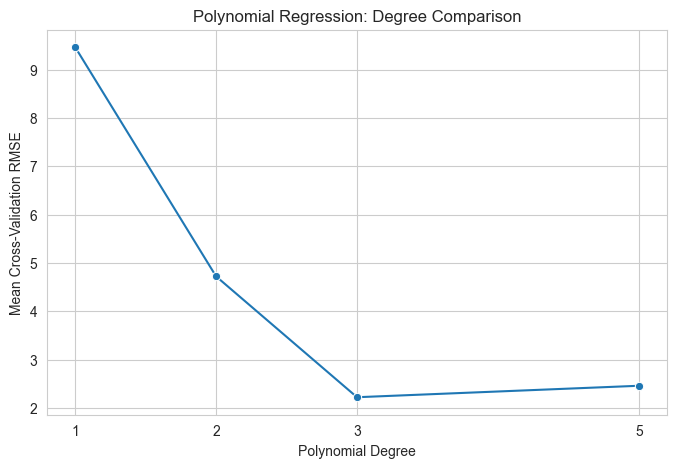

In [32]:
plt.figure(figsize=(8, 5))
sns.lineplot(data = polynomial_results, x="Degree", y="Mean CV RMSE", marker="o")
plt.title("Polynomial Regression: Degree Comparison")
plt.xlabel("Polynomial Degree")
plt.ylabel("Mean Cross-Validation RMSE")
plt.xticks([1, 2, 3, 5])
plt.show()

## Principal Component Regression 
Principal Component Regression (PCR) uses PCA to summarize variables into a small number of components. A linear regression model is then fitted using those components. 

Our proposal suggested comparing up to 10 components. However, we use 9 environmental predictors, so the maximum possible number of components is 9.

We compare '1', '2', '3', '5', and '9' principal components. 

In [33]:
pcr_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("pca", PCA()),
    ("LinearRegression", LinearRegression())
])

pcr_search = GridSearchCV(
    estimator=pcr_pipeline,
    param_grid={
        "pca__n_components": [1, 2, 3, 5, 9]
    },
    scoring="neg_root_mean_squared_error",
    cv=cv
)

pcr_search.fit(X_train, y_train)

print("Best number of components:", pcr_search.best_params_["pca__n_components"])
print("Best CV RMSE:", -pcr_search.best_score_) 

Best number of components: 9
Best CV RMSE: 9.462887979018387


In [34]:
pcr_results = pd.DataFrame({
    "Number of Components": pcr_search.cv_results_["param_pca__n_components"].astype(int),
    "Mean CV RMSE": -pcr_search.cv_results_["mean_test_score"]
}).sort_values("Number of Components")

pcr_results

,Number of Components,Mean CV RMSE
0,1,12.506739
1,2,12.182722
2,3,11.941964
3,5,10.428318
4,9,9.462888


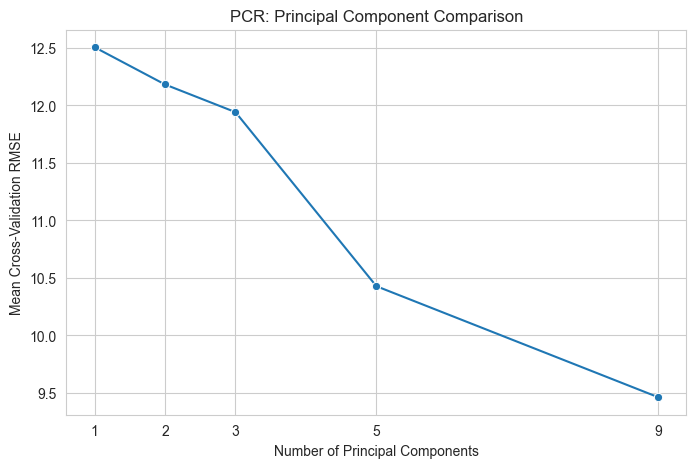

In [35]:
plt.figure(figsize=(8, 5))
sns.lineplot(data = pcr_results, x="Number of Components", y="Mean CV RMSE", marker="o")
plt.title("PCR: Principal Component Comparison")
plt.xlabel("Number of Principal Components")
plt.ylabel("Mean Cross-Validation RMSE")
plt.xticks([1, 2, 3, 5, 9])
plt.show()

## Final Model Comparison 
This section compares final performance on the held-out test set.

How to read the output:
- Lower test RMSE values indicate better predictions. 
- Higher test R-squared values indicate that a model explains more variation in 'HealthImpactScore'. 
- The test set was not used when selecting hyperparameters, so it provides a final model comparison.


In [36]:
best_models = {
    "Multiple Linear Regression": linear_model,
    "Lasso Regression": lasso_search.best_estimator_,
    "Polynomial Regression": polynomia_search.best_estimator_,
    "Principal Component Regression": pcr_search.best_estimator_
}

compaison_results = pd.DataFrame([
    test_summary(model_name, model)
    for model_name, model in best_models.items()
]).sort_values("Test RMSE")

compaison_results

,Model,Test RMSE,Test R-squared
2,Polynomial Regression,2.303857,0.971672
0,Multiple Linear Regression,9.634493,0.504587
3,Principal Component Regression,9.634493,0.504587
1,Lasso Regression,9.637538,0.504274


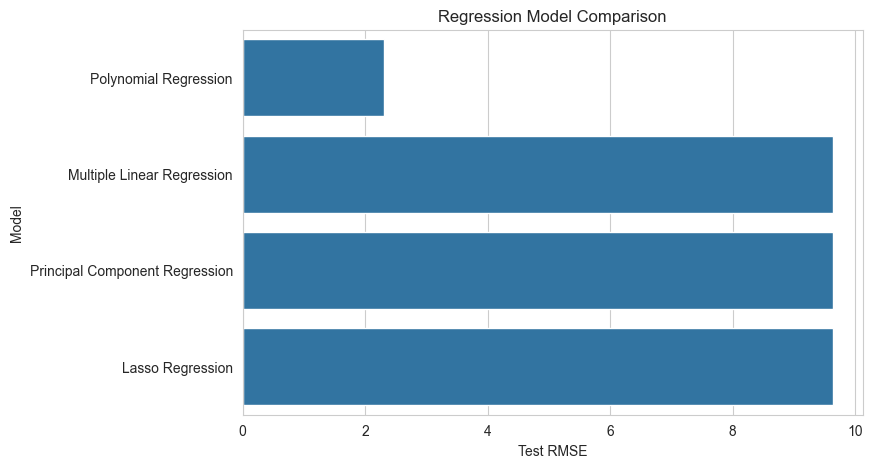

In [37]:
plt.figure(figsize=(8, 5))
sns.barplot(data=compaison_results, x="Test RMSE", y="Model")
plt.title("Regression Model Comparison")
plt.xlabel("Test RMSE")
plt.ylabel("Model")
plt.show()

## Conclusion

Polynomial Regression performed best for predicting `HealthImpactScore`. The selected polynomial degree was `3`, with a test RMSE of approximately `2.304` and a test R-squared value of approximately `0.972`. This means that the model explained about 97.2% of the variation in `HealthImpactScore` within the held-out test set.

The Multiple Linear Regression baseline produced a test RMSE of approximately `9.634` and a test R-squared value of approximately `0.505`. Lasso Regression selected an alpha value of approximately `0.032`, but it did not improve test performance compared with the baseline linear model. This suggests that Lasso regularization was not especially useful for this prediction task.

Principal Component Regression selected all `9` principal components. Its performance was nearly identical to the Multiple Linear Regression baseline. This indicates that reducing the number of components did not improve prediction accuracy.

Overall, the Polynomial Regression results suggest that the relationship between environmental variables and `HealthImpactScore` is nonlinear. Within this dataset, air quality and weather variables are strongly associated with the health impact score. However, these results show predictive relationships and should not be interpreted as proof of causation.